In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import joblib

In [2]:
daily = pd.read_csv(
    "../data/processed/daily_sales.csv"
)

daily.head()

,Date,TotalPrice,Rolling_7,Rolling_30
0,2009-12-01,43894.87,NaN,NaN
1,2009-12-02,52762.06,NaN,NaN
2,2009-12-03,67413.62,NaN,NaN
3,2009-12-04,33913.81,NaN,NaN
4,2009-12-05,9803.05,NaN,NaN


In [3]:
daily = daily.rename(
    columns={
        "Date":"ds",
        "TotalPrice":"y"
    }
)

daily["ds"] = pd.to_datetime(daily["ds"])

daily = daily[["ds","y"]]

daily.head()

,ds,y
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


In [4]:
train = daily.iloc[:-30]

test = daily.iloc[-30:]

print("Training:", train.shape)

print("Testing :", test.shape)

Training: (344, 2)
Testing : (30, 2)


In [5]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

In [6]:
model.fit(train)

22:00:32 - cmdstanpy - INFO - Chain [1] start processing
22:00:32 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
future = model.make_future_dataframe(
    periods=30
)

In [8]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2009-12-01,22863.888278,38050.996854,63982.528294,22863.888278,22863.888278,28234.300481,28234.300481,28234.300481,6625.862082,6625.862082,6625.862082,21608.438398,21608.438398,21608.438398,0.0,0.0,0.0,51098.188759
1,2009-12-02,22867.399377,35595.070837,60539.806292,22867.399377,22867.399377,24686.820475,24686.820475,24686.820475,3767.379718,3767.379718,3767.379718,20919.440756,20919.440756,20919.440756,0.0,0.0,0.0,47554.219851
2,2009-12-03,22870.910475,40811.453829,66274.529104,22870.910475,22870.910475,30631.027344,30631.027344,30631.027344,10563.955785,10563.955785,10563.955785,20067.071559,20067.071559,20067.071559,0.0,0.0,0.0,53501.937819
3,2009-12-04,22874.421574,30091.301795,54374.802197,22874.421574,22874.421574,20099.227595,20099.227595,20099.227595,1047.959127,1047.959127,1047.959127,19051.268468,19051.268468,19051.268468,0.0,0.0,0.0,42973.649169
4,2009-12-05,22877.932672,5153.843841,32050.522505,22877.932672,22877.932672,-4118.405556,-4118.405556,-4118.405556,-21993.077025,-21993.077025,-21993.077025,17874.671469,17874.671469,17874.671469,0.0,0.0,0.0,18759.527116


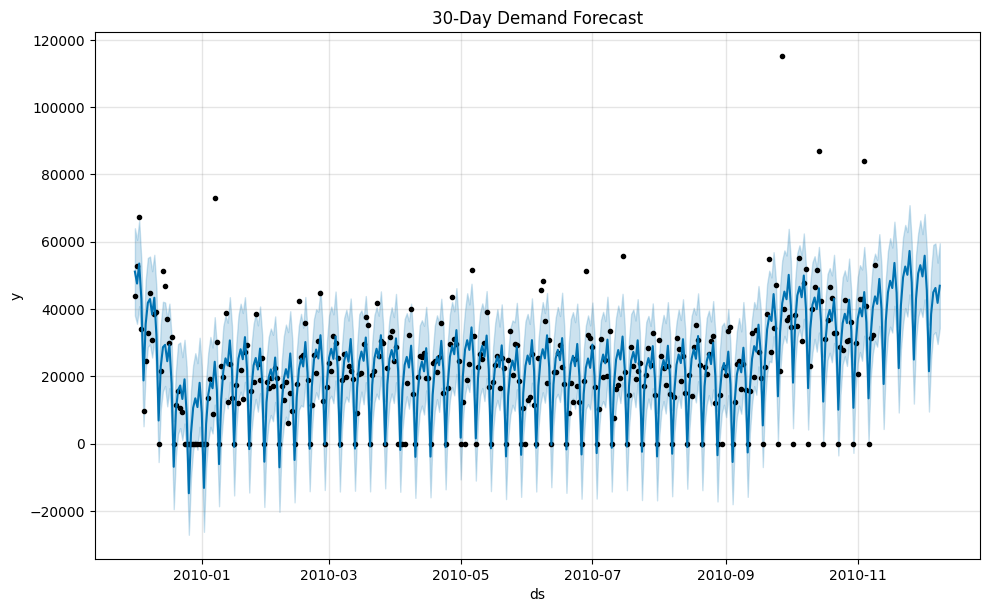

In [9]:
fig = model.plot(forecast)

plt.title("30-Day Demand Forecast")

plt.show()

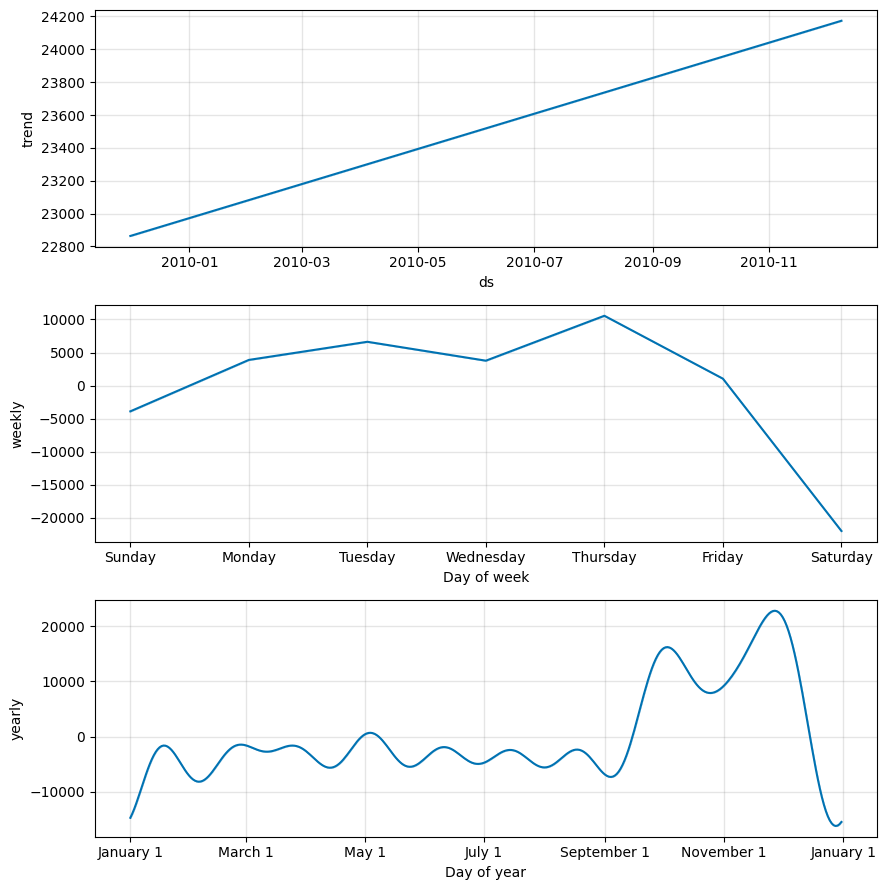

In [10]:
model.plot_components(forecast)

plt.show()

In [11]:
pred = forecast[["ds","yhat"]].tail(30)

pred = pred.reset_index(drop=True)

test = test.reset_index(drop=True)

In [12]:
mae = mean_absolute_error(
    test["y"],
    pred["yhat"]
)

rmse = np.sqrt(
    mean_squared_error(
        test["y"],
        pred["yhat"]
    )
)

mape = (
    np.mean(
        np.abs(
            (test["y"] - pred["yhat"])
            / test["y"]
        )
    )
    *100
)

print("MAE :", mae)

print("RMSE:", rmse)

print("MAPE:", mape)

MAE : 11823.824475107665
RMSE: 14133.80811294165
MAPE: inf


In [13]:
mask = test["y"] != 0

mape = (
    np.mean(
        np.abs(
            (test.loc[mask, "y"] - pred.loc[mask, "yhat"])
            / test.loc[mask, "y"]
        )
    )
    * 100
)

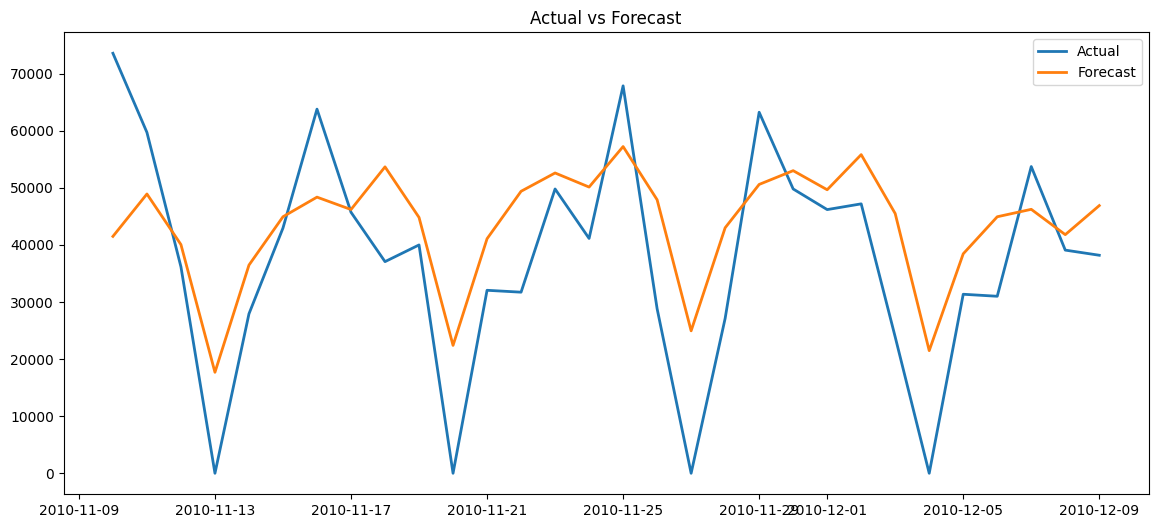

In [14]:
plt.figure(figsize=(14,6))

plt.plot(
    test["ds"],
    test["y"],
    label="Actual",
    linewidth=2
)

plt.plot(
    pred["ds"],
    pred["yhat"],
    label="Forecast",
    linewidth=2
)

plt.legend()

plt.title("Actual vs Forecast")

plt.show()

In [15]:
future_30 = model.make_future_dataframe(
    periods=30
)

forecast_30 = model.predict(future_30)

forecast_30.tail(30)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
344,2010-11-10,24071.869070,29788.467449,54260.995229,24071.869070,24071.869070,17426.206196,17426.206196,17426.206196,3767.379718,3767.379718,3767.379718,13658.826477,13658.826477,13658.826477,0.0,0.0,0.0,41498.075266
345,2010-11-11,24075.380676,36146.196174,62148.604790,24075.380676,24075.380676,24852.147852,24852.147852,24852.147852,10563.955785,10563.955785,10563.955785,14288.192067,14288.192067,14288.192067,0.0,0.0,0.0,48927.528528
346,2010-11-12,24078.892282,27169.941720,53449.228825,24078.892282,24078.892282,15985.078039,15985.078039,15985.078039,1047.959127,1047.959127,1047.959127,14937.118913,14937.118913,14937.118913,0.0,0.0,0.0,40063.970321
347,2010-11-13,24082.403888,5225.069057,30446.509302,24082.403877,24082.403898,-6390.480116,-6390.480116,-6390.480116,-21993.077025,-21993.077025,-21993.077025,15602.596909,15602.596909,15602.596909,0.0,0.0,0.0,17691.923772
348,2010-11-14,24085.915494,23155.067491,48931.021087,24085.915470,24085.915516,12385.685655,12385.685655,12385.685655,-3895.191604,-3895.191604,-3895.191604,16280.877258,16280.877258,16280.877258,0.0,0.0,0.0,36471.601149
349,2010-11-15,24089.427100,32038.370372,58699.391395,24089.427058,24089.427137,20850.458160,20850.458160,20850.458160,3883.111916,3883.111916,3883.111916,16967.346244,16967.346244,16967.346244,0.0,0.0,0.0,44939.885260
350,2010-11-16,24092.938706,34681.951003,61211.508092,24092.938646,24092.938754,24282.284355,24282.284355,24282.284355,6625.862082,6625.862082,6625.862082,17656.422273,17656.422273,17656.422273,0.0,0.0,0.0,48375.223061
351,2010-11-17,24096.450312,32694.407889,58180.845985,24096.450222,24096.450377,22108.862109,22108.862109,22108.862109,3767.379718,3767.379718,3767.379718,18341.482391,18341.482391,18341.482391,0.0,0.0,0.0,46205.312421
352,2010-11-18,24099.961918,41274.278499,66177.635399,24099.961802,24099.962001,29578.779394,29578.779394,29578.779394,10563.955785,10563.955785,10563.955785,19014.823609,19014.823609,19014.823609,0.0,0.0,0.0,53678.741312
353,2010-11-19,24103.473524,32569.960561,57564.519422,24103.473385,24103.473630,20715.622493,20715.622493,20715.622493,1047.959127,1047.959127,1047.959127,19667.663367,19667.663367,19667.663367,0.0,0.0,0.0,44819.096017


In [16]:
forecast_30.to_csv(
    "../data/processed/forecast_prophet.csv",
    index=False
)

In [17]:
joblib.dump(
    model,
    "../models/prophet_model.pkl"
)

['../models/prophet_model.pkl']

In [18]:
print("Forecast Shape:", forecast_30.shape)

print("MAE :", mae)

print("RMSE:", rmse)

print("MAPE:", mape)

Forecast Shape: (374, 19)
MAE : 11823.824475107665
RMSE: 14133.80811294165
MAPE: 26.74523723397292
